# Evaluate — Xception Baseline (Intra-FF++ C23)

## 📋 Hướng dẫn Input Kaggle

Vào **Data → Add Input** và thêm các dataset sau:

| Dataset | Nội dung | Biến đường dẫn |
| :--- | :--- | :--- |
| `thinhphan272/ffpp-c23-face-cache` | Ảnh frame đã crop + manifest | `CACHE_DIR` |
| Dataset chứa `xception_best.pth` | Checkpoint + `train_history.csv` | `BEST_PATH`, `TRAIN_HISTORY_CSV` |

> **Lưu ý**: Đây là notebook **evaluate-only** — không train lại, chỉ load checkpoint và đánh giá test set.


## 1. Cấu hình đường dẫn

In [1]:
import os, glob, time, random, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA CÁC ĐƯỜNG DẪN NÀY ====================
CACHE_DIR       = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"
MANIFEST_CSV    = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX      = "/kaggle/working/ffpp_c23_cache"

BEST_PATH       = "/kaggle/input/datasets/thinhphan1506/xception-baseline-pth/xception_baseline/xception_best.pth"
TRAIN_HISTORY_CSV = os.path.join(os.path.dirname(BEST_PATH), "train_history.csv")
OUT_DIR         = "/kaggle/working/eval_xception"
# ================================================================

DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE        = 299
FRAMES_PER_VIDEO_EVAL = 16
TEST_BATCH_SIZE = 1

os.makedirs(OUT_DIR, exist_ok=True)
assert os.path.isdir(CACHE_DIR), f"Không tìm thấy CACHE_DIR: {CACHE_DIR}"
assert os.path.exists(BEST_PATH), f"Không tìm thấy checkpoint: {BEST_PATH} — kiểm tra BEST_PATH!"
print(f"Device: {DEVICE}")
print(f"Checkpoint: {BEST_PATH} ({round(os.path.getsize(BEST_PATH)/1e6, 1)} MB)")
print(f"train_history.csv: {'tồn tại ✓' if os.path.exists(TRAIN_HISTORY_CSV) else 'không tìm thấy ⚠'}")


Device: cuda
Checkpoint: /kaggle/input/datasets/thinhphan1506/xception-baseline-pth/xception_baseline/xception_best.pth (83.6 MB)
train_history.csv: tồn tại ✓


## 2. Đọc manifest, lấy tập test

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest["out_dir"] = manifest["out_dir"].str.replace(OLD_PREFIX, CACHE_DIR, regex=False)

manifest_ok = manifest[
    manifest["status"].isin(["ok", "skip_exists"]) & (manifest["n_frames"] >= 8)
].reset_index(drop=True)

test_df = manifest_ok[manifest_ok["split"] == "test"].reset_index(drop=True)
print(f"Test videos: {len(test_df)}")
print(test_df.groupby(["label", "method"])["video_id"].count())


Test videos: 700
label  method        
0      original          140
1      Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
Name: video_id, dtype: int64


## 3. Dataset & DataLoader (Video-level eval, chỉ test set)

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_frame_eval(path, img_size=IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        return torch.zeros(3, img_size, img_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size)).astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1))

class FFPPVideoEvalDataset(Dataset):
    def __init__(self, df, frames_per_video=FRAMES_PER_VIDEO_EVAL, img_size=IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.fpv = frames_per_video
        self.img_size = img_size

    def __len__(self): return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        frames_dir = row["out_dir"]
        paths = sorted(glob.glob(os.path.join(frames_dir, "*.jpg")))
        if not paths:
            paths = sorted(glob.glob(os.path.join(frames_dir, "*.png")))
        if not paths:
            frames = torch.zeros(self.fpv, 3, self.img_size, self.img_size)
        else:
            step = max(len(paths) // self.fpv, 1)
            sel = paths[::step][:self.fpv]
            while len(sel) < self.fpv:
                sel = sel + sel
            sel = sel[:self.fpv]
            frames = torch.stack([load_frame_eval(p, self.img_size) for p in sel])
        label = int(row["label"])
        method = str(row.get("method", "unknown"))
        return frames, label, method, str(row["video_id"])

test_ds = FFPPVideoEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test DataLoader: {len(test_ds)} videos")


Test DataLoader: 700 videos


## 4. Kiến trúc mô hình Xception (copy từ training notebook — PHẢI khớp 100%)

In [4]:
import timm

class XceptionDetector(nn.Module):
    """Kiến trúc đúng theo Appendix D.2 của paper FF++ gốc:
    timm legacy_xception + 1 lớp Linear(2048, 1) binary classification."""
    def __init__(self, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model("legacy_xception", pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features
        self.classifier = nn.Linear(feat_dim, 1)

    def forward(self, x):
        feat = self.backbone(x)
        return self.classifier(feat).squeeze(-1)

model = XceptionDetector(pretrained=False).to(DEVICE)
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"Mô hình Xception: {n_params/1e6:.2f}M tham số")


Mô hình Xception: 20.81M tham số


## 5. Hàm tính metric chuẩn hóa

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import numpy as np

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fp / max(fp + tn, 1)
    frr = fn / max(fn + tp, 1)
    return far, frr

def calc_far_frr_curve(y_true, y_score, n_points=200):
    thresholds = np.linspace(0, 1, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr = calc_far_frr(y_true, y_score, t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_score)
    acc = accuracy_score(y_true, y_pred)
    eer = calc_eer(y_true, y_score)
    eer_thr = find_eer_threshold(y_true, y_score)
    far05, frr05 = calc_far_frr(y_true, y_score, 0.5)
    far_eer, frr_eer = calc_far_frr(y_true, y_score, eer_thr)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return {
        "auc": auc, "acc": acc, "eer": eer, "eer_threshold": eer_thr,
        "far_at_0.5": far05, "frr_at_0.5": frr05,
        "far_at_eer": far_eer, "frr_at_eer": frr_eer,
        "cm_at_0.5": cm, "roc_fpr": fpr, "roc_tpr": tpr
    }


## 6. Hàm vẽ biểu đồ chuẩn hóa

In [6]:
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Confusion Matrix CHUẨN HÓA
# ══════════════════════════════════════════════════════════════════════════════
def plot_confusion_matrix_standard(cm, model_name, out_path=None, threshold=0.5):
    fig, ax = plt.subplots(figsize=(6.0, 5.2), dpi=150)
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    classes = ["Real (0)", "Fake (1)"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(classes, fontsize=12, fontweight="bold")
    ax.set_yticks([0, 1]); ax.set_yticklabels(classes, fontsize=12, fontweight="bold")
    total = np.sum(cm); thresh = cm.max() / 2.0
    labels_tag = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = count / total * 100 if total > 0 else 0
            tag = labels_tag[i][j]
            color = "white" if count > thresh else "#08306b"
            ax.text(j, i, f"{tag}\n{count:,}\n({pct:.1f}%)",
                    ha="center", va="center", color=color,
                    fontsize=13, fontweight="bold", linespacing=1.3)
    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_title(f"Confusion Matrix @ threshold={threshold}\n{model_name}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Training Curves CHUẨN HÓA
# ══════════════════════════════════════════════════════════════════════════════
def plot_training_curves_standard(hist_df, model_name, out_path=None):
    epochs = hist_df["epoch"].values
    train_loss = hist_df["train_loss"].values if "train_loss" in hist_df.columns else None
    val_loss, vl_label = None, "Val Loss"
    for col in ["val_loss", "val_loss_ema", "val_loss_raw"]:
        if col in hist_df.columns:
            val_loss = hist_df[col].values
            if "ema" in col: vl_label = "Val Loss (EMA)"
            elif "raw" in col: vl_label = "Val Loss (Raw)"
            break
    val_auc = next((hist_df[c].values for c in ["val_auc","val_auc_ema","val_auc_raw"] if c in hist_df.columns), None)
    val_eer = next((hist_df[c].values for c in ["val_eer","val_eer_ema","val_eer_raw"] if c in hist_df.columns), None)
    val_acc = next((hist_df[c].values for c in ["val_acc","val_acc_ema","val_acc_raw"] if c in hist_df.columns), None)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), dpi=120)
    # Panel 1: Loss
    ax = axes[0]
    if train_loss is not None:
        ax.plot(epochs, train_loss, "o-", color="#1f77b4", lw=2, ms=4, label="Train Loss")
    if val_loss is not None:
        ax.plot(epochs, val_loss, "s--", color="#d62728", lw=2, ms=4, label=vl_label)
        bi = int(np.argmin(val_loss))
        ax.scatter([epochs[bi]], [val_loss[bi]], color="#d62728", s=100, zorder=5,
                   edgecolors="black", marker="*", label=f"Min Val Loss ({val_loss[bi]:.4f})")
    ax.set_title("Loss (Train vs Val)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")
    # Panel 2: AUC
    ax = axes[1]
    if val_auc is not None:
        ax.plot(epochs, val_auc, "^-", color="#2ca02c", lw=2, ms=4, label="Val AUC")
        bi = int(np.argmax(val_auc))
        ax.scatter([epochs[bi]], [val_auc[bi]], color="#2ca02c", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best AUC ({val_auc[bi]*100:.2f}%)")
    ax.set_title("Val AUC", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")
    # Panel 3: EER
    ax = axes[2]
    if val_eer is not None:
        ax.plot(epochs, val_eer * 100, "v-", color="#9467bd", lw=2, ms=4, label="Val EER (%)")
        bi = int(np.argmin(val_eer))
        ax.scatter([epochs[bi]], [val_eer[bi]*100], color="#9467bd", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Min EER ({val_eer[bi]*100:.2f}%)")
    ax.set_title("Val EER (lower is better)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("EER (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")
    # Panel 4: Accuracy
    ax = axes[3]
    if val_acc is not None:
        ax.plot(epochs, val_acc * 100, "d-", color="#17becf", lw=2, ms=4, label="Val Acc (%)")
        bi = int(np.argmax(val_acc))
        ax.scatter([epochs[bi]], [val_acc[bi]*100], color="#17becf", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best Acc ({val_acc[bi]*100:.2f}%)")
    ax.set_title("Val Accuracy", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")

    plt.suptitle(f"Training Progress — {model_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


## 7. Load checkpoint + Đánh giá test (có TTA lật ngang)

Loaded checkpoint from epoch 9 (val_auc=0.9939668367346939)


Evaluating test set: 100%|██████████| 700/700 [03:06<00:00,  3.75it/s]



=== KẾT QUẢ TEST (FF++ C23) — Xception Baseline + TTA ===
Accuracy            : 97.29%
AUC                 : 99.16%
EER                 : 2.86%
FAR @ threshold=0.5 : 3.57%
FRR @ threshold=0.5 : 2.50%
FAR @ EER           : 3.57%  |  FRR @ EER: 2.86%

Confusion Matrix @ 0.5:  TN=135  FP=5  FN=14  TP=546


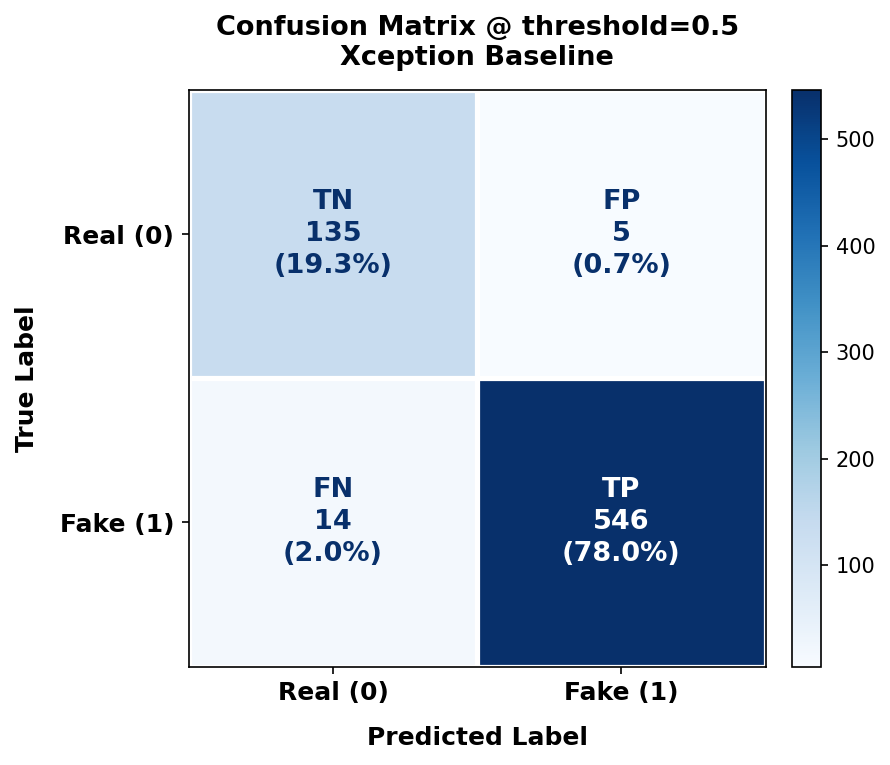

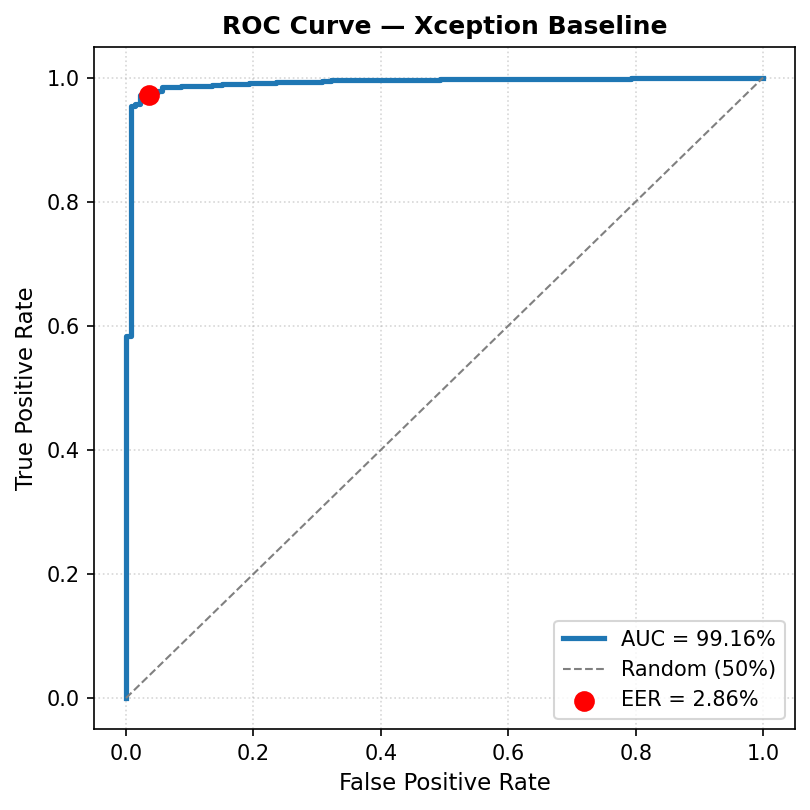

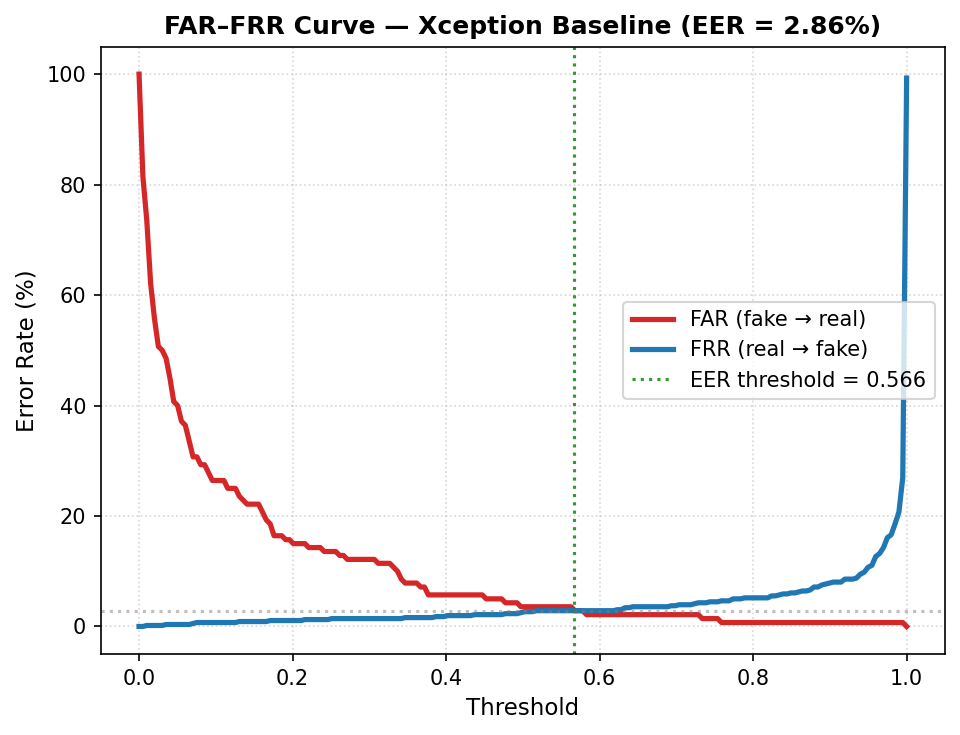


=== Breakdown theo phương pháp (real + từng loại fake) ===
        method  n_real  n_fake      auc      eer
NeuralTextures     140     140 0.981939 0.050000
      FaceSwap     140     140 0.992704 0.021429
     Face2Face     140     140 0.994898 0.028571
     Deepfakes     140     140 0.996735 0.021429

✓ Đã lưu toàn bộ kết quả vào /kaggle/working/eval_xception/


In [7]:
MODEL_NAME = "Xception Baseline"

@torch.no_grad()
def evaluate(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score, methods = [], [], []
    for frames, label, method, vid in tqdm(loader, desc="Evaluating test set"):
        frames = frames.squeeze(0).to(DEVICE)          # [T, C, H, W]
        frames_flip = torch.flip(frames, dims=[3])      # TTA: lật ngang

        # Average pooling over frames
        logits_orig = eval_model(frames).mean(0, keepdim=True)
        if use_tta:
            logits_flip = eval_model(frames_flip).mean(0, keepdim=True)
            prob = (torch.sigmoid(logits_orig) + torch.sigmoid(logits_flip)) / 2.0
        else:
            prob = torch.sigmoid(logits_orig)
        y_score.append(prob.squeeze().item())
        y_true.append(label.item())
        methods.append(method[0] if isinstance(method, (list, tuple)) else method)

    return np.array(y_true), np.array(y_score)

# Load checkpoint
ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model = XceptionDetector(pretrained=False).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
val_auc_log = ckpt.get('val_metrics', {}).get('auc', 'N/A')
print(f"Loaded checkpoint from epoch {ckpt.get('epoch', '?')} (val_auc={val_auc_log})")

y_true, y_score = evaluate(model, test_loader, use_tta=True)
test_metrics = calc_metrics(y_true, y_score)

print(f"\n=== KẾT QUẢ TEST (FF++ C23) — {MODEL_NAME} + TTA ===")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
print(f"FAR @ EER           : {test_metrics['far_at_eer']*100:.2f}%  |  FRR @ EER: {test_metrics['frr_at_eer']*100:.2f}%")

cm = test_metrics["cm_at_0.5"]
print(f"\nConfusion Matrix @ 0.5:  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

# ── 1. Confusion Matrix CHUẨN HÓA ──
plot_confusion_matrix_standard(cm, MODEL_NAME,
                                out_path=os.path.join(OUT_DIR, "confusion_matrix.png"))

# ── 2. ROC Curve ──
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=150)
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2.5, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]],
           color="red", zorder=5, s=80, label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate", fontsize=11); ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"ROC Curve — {MODEL_NAME}", fontsize=12, fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

# ── 3. FAR–FRR Curve ──
thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)
ax.plot(thr, fars * 100, lw=2.5, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2.5, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.8,
           label=f"EER threshold = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Threshold", fontsize=11); ax.set_ylabel("Error Rate (%)", fontsize=11)
ax.set_title(f"FAR–FRR Curve — {MODEL_NAME} (EER = {test_metrics['eer']*100:.2f}%)",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

# ── 4. Breakdown theo phương pháp fake ──
test_ordered = test_df.reset_index(drop=True)
assert len(test_ordered) == len(y_true), "Mismatch: test_df and y_true lengths differ!"
rows = []
real_mask = test_ordered["label"].values == 0
for method in sorted(test_ordered.loc[~real_mask, "method"].unique()):
    mm = test_ordered["method"].values == method
    sel = real_mask | mm
    m = calc_metrics(y_true[sel], y_score[sel])
    rows.append({"method": method, "n_real": int(real_mask.sum()),
                 "n_fake": int(mm.sum()), "auc": m["auc"], "eer": m["eer"]})
bd = pd.DataFrame(rows).sort_values("auc")
bd.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== Breakdown theo phương pháp (real + từng loại fake) ===")
print(bd.to_string(index=False))

# ── 5. Lưu test_results_intra.csv ──
n_params = sum(p.numel() for p in model.parameters())
result_row = {
    "model": "Xception", "input_modality": "spatial_rgb",
    "params_M": round(n_params / 1e6, 2),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "acc_intra": test_metrics["acc"], "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
}
for _, r in bd.iterrows():
    result_row[f"auc_{r['method']}"] = r["auc"]
    result_row[f"eer_{r['method']}"] = r["eer"]
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\n✓ Đã lưu toàn bộ kết quả vào {OUT_DIR}/")


## 8. Training Curves (đọc từ train_history.csv)

Đã tải 18 epochs từ /kaggle/input/datasets/thinhphan1506/xception-baseline-pth/xception_baseline/train_history.csv


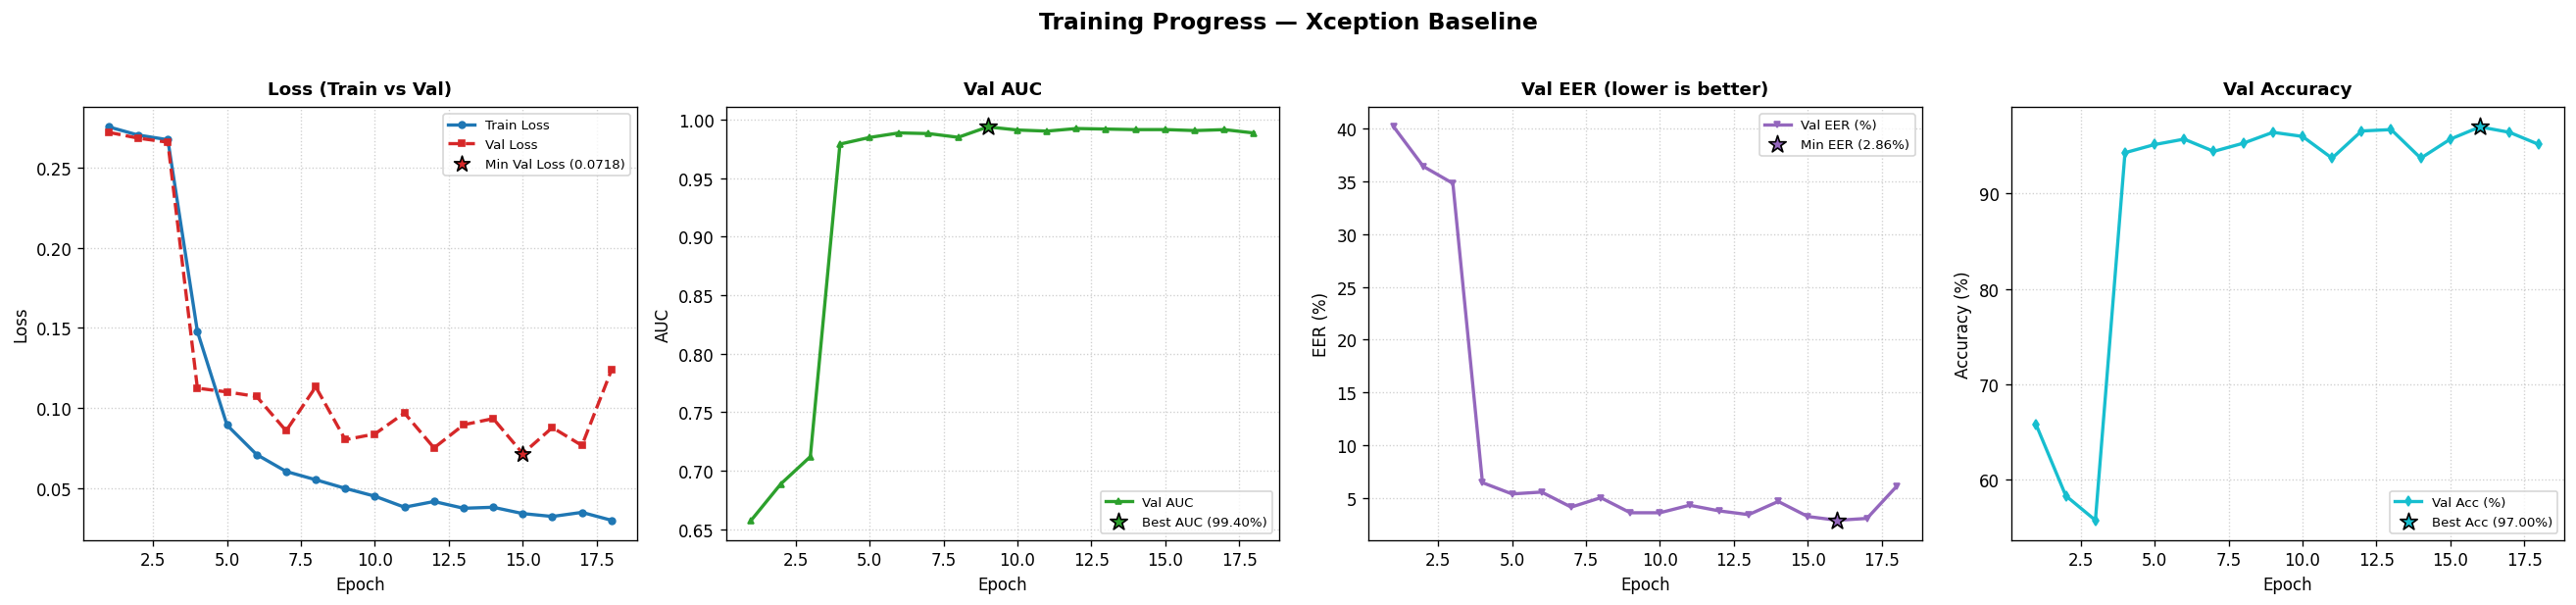

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Vẽ Training Curves CHUẨN HÓA (đọc từ train_history.csv kèm checkpoint)
# ══════════════════════════════════════════════════════════════════════════════
if os.path.exists(TRAIN_HISTORY_CSV):
    hist_df = pd.read_csv(TRAIN_HISTORY_CSV)
    print(f"Đã tải {len(hist_df)} epochs từ {TRAIN_HISTORY_CSV}")
    plot_training_curves_standard(hist_df, MODEL_NAME,
                                   out_path=os.path.join(OUT_DIR, "training_curves.png"))
else:
    print(f"⚠️ Không tìm thấy {TRAIN_HISTORY_CSV} — bỏ qua Training Curves.")
    print("   Thêm train_history.csv vào Kaggle Input cùng thư mục với checkpoint để hiển thị.")


## 9. ⚠️ Lưu kết quả

**Save Version → Save & Run All (Commit)** → tab **Output** → **New Dataset** để lưu:
- `confusion_matrix.png`, `roc_curve.png`, `far_frr_curve.png`, `training_curves.png`
- `auc_breakdown_by_method.csv`
